# Kerala University Affiliated Colleges

In [54]:
import requests
from bs4 import BeautifulSoup
import re
import pandas as pd

In [46]:
#load webpage
url="https://www.keralauniversity.ac.in/affiliated-colleges"
response=requests.get(url)
print(response.status_code)

200


In [47]:
soup=BeautifulSoup(response.text,"html.parser")

In [48]:
college_name=soup.find_all("h4")
print("Count of colleges:",len(college_name))
# for college in college_name:
#     print(college.text.strip())

Count of colleges: 206


In [49]:
print(college_name)

[<h4 class="role-title">University of Kerala</h4>, <h4>Affiliated Colleges</h4>, <h4 style="text-align:left"><a href="http://www.ajcollege.in" style="color:#FFF; text-decoration:none" target="_blank">A. J. College of Science and Technology, Thonnakkal</a></h4>, <h4 style="text-align:left"><a href="http://www.allsaintscollege.ac.in" style="color:#FFF; text-decoration:none" target="_blank">All Saints' College, Thiruvananthapuram</a></h4>, <h4 style="text-align:left"><a href="http://www.aimmba.com" style="color:#FFF; text-decoration:none" target="_blank">Allama Iqbal Institute of Management, Peringamala, Thiruvananthapuram</a></h4>, <h4 style="text-align:left"><a href="http://www.akmascollege.com" style="color:#FFF; text-decoration:none" target="_blank">Ayyankali Memorial Arts and Science College, Kuryottumala, Vettithitta P. O., Pathanapuram</a></h4>, <h4 style="text-align:left"><a href="http://www.bnvtrust.org" style="color:#FFF; text-decoration:none" target="_blank">B.N.V. College of T

In [50]:
for college in college_name:
    print(college.text.strip())

University of Kerala
Affiliated Colleges
A. J. College of Science and Technology, Thonnakkal
All Saints' College, Thiruvananthapuram
Allama Iqbal Institute of Management, Peringamala, Thiruvananthapuram
Ayyankali Memorial Arts and Science College, Kuryottumala, Vettithitta P. O., Pathanapuram
B.N.V. College of Teacher Education, Thiruvallam, Thiruvananthapuram
Baby John Memorial Govt. College, Chavara
Badhiriya B.Ed. Training College, Velichikkala, Kollam
Baselios Marthoma Mathews II Training College, Kottarakara
Bishop Jerome School of Architecture, Fathima College Road, Kollam
Bishop Jesudasan CSI Arts & Science College, Mulayara, Thiruvananthapuram
Bishop Moore College for the Hearing Impaired, Manakala, Adoor
Bishop Moore College, Mavelikkara, Alappuzha
Buddha College of Teacher Education, Cheppad, Muthukulam North, Alappuzha
C. H. M. M. College for Advanced Studies, Chavarcode, Varkala
Carmel College, Muhamma, Alappuzha
Christ College, Vizhinjam, Thiruvananthapuram
Christ Nagar Ch

In [55]:
from urllib.parse import urljoin
college_data = []
for college in college_name:
    name = college.text.strip()
    if name != "University of Kerala" and name != "Affiliated Colleges":
       # print("College Name:", name)
        phone = []
        email = []
        text = ""
        read_more = college.find_next("a")
        if read_more and read_more.get("href"):
            college_url = urljoin("https://www.keralauniversity.ac.in", read_more["href"])
            
            try:
                page = requests.get(college_url)
                college_soup = BeautifulSoup(page.text, "html.parser")
                text = college_soup.get_text(" ", strip=True) 
                phon = re.findall(r'(?:\+91[\s-]?)?\d{3,5}[-\s]?\d{6,8}',text)
                for a in college_soup.find_all("a", href=True):

                    href = a["href"]

                    if href.startswith("tel:"):
                        phon.append(href.replace("tel:", "").strip())

                phone = list(set(phon))
                email = re.findall(r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}',text)
                address = "N/A"
                address_keywords = ["address","location","locate us","contact address","reach us"]

                for tag in college_soup.find_all(["div","section","p","li"]):
                    tag_text = tag.get_text(" ", strip=True).lower()
                    for keyword in address_keywords:
                        if (len(tag_text) < 300 and (
                            "kerala" in tag_text.lower() or "thiruvananthapuram" in tag_text.lower() or "address" in tag_text.lower() or "Locate Us" in tag_text.lower() 
                        )):
                          address = tag.get_text(" ",strip=True)
                          break

                
            except Exception as e:
                print("Error:", e)
                continue
        
            if phone or name or email or address:  
                college_web = college_url if college_url else "N/A"
                #addr = text[:200] if text else "N/A"
                #addres = address[0].text.strip()
                addr = address if address else "N/A"
                nme = name if name else "N/A"
                phone_no = phone[0] if phone else "N/A"
                e_id = email[0] if email else "N/A"
                print("College Name:", nme)           
                print("Address:", address)
                print("website:", college_web)
                print(f"Contact:{phone_no}")
                print("Email ID:", e_id)
      
            else:
                print("N/A")
    college_data.append({
        "College Name": name,
        "Address": address,
        "website": college_url,
        "Contact": ", ".join(phone) if phone else "N/A",
        "Email ID": email[0] if email else "N/A"
    })


df = pd.DataFrame(college_data)
        # else:
            # print("Read More link not found")

College Name: A. J. College of Science and Technology, Thonnakkal
Address: Kerala  - 695 317
website: http://www.ajcollege.in
Contact:+91 471 2618106
Email ID: ajcollegeprincipal@gmail.com
College Name: All Saints' College, Thiruvananthapuram
Address: All Saints' College Thiruvananthapuram -695007 +91 8304 841 778 allsaintscolegeasc@gmail.com
website: http://www.allsaintscollege.ac.in
Contact:N/A
Email ID: allsaintscolegeasc@gmail.com
College Name: Allama Iqbal Institute of Management, Peringamala, Thiruvananthapuram
Address: Your Web address means everything watch our video see why
website: http://www.aimmba.com
Contact:1-303-893-0552
Email ID: N/A
College Name: Ayyankali Memorial Arts and Science College, Kuryottumala, Vettithitta P. O., Pathanapuram
Address: N/A
website: http://www.akmascollege.com
Contact:N/A
Email ID: N/A
Error: HTTPConnectionPool(host='www.bnvtrust.org', port=80): Max retries exceeded with url: / (Caused by NameResolutionError("<urllib3.connection.HTTPConnection 

## To data frame

In [56]:
df = pd.DataFrame(college_data)
print(df.head())

# save csv

df.to_csv("Kerala_University_Affiliated_Collegess.csv",index=False)
print("Completed")

                                        College Name  \
0                               University of Kerala   
1                                Affiliated Colleges   
2  A. J. College of Science and Technology, Thonn...   
3            All Saints' College, Thiruvananthapuram   
4  Allama Iqbal Institute of Management, Peringam...   

                                             Address  \
0  White Memorial College of Arts & Science, Pana...   
1  White Memorial College of Arts & Science, Pana...   
2                                  Kerala  - 695 317   
3  All Saints' College Thiruvananthapuram -695007...   
4  Your Web address means everything watch our vi...   

                             website  \
0              http://www.wmctvm.com   
1              http://www.wmctvm.com   
2            http://www.ajcollege.in   
3  http://www.allsaintscollege.ac.in   
4              http://www.aimmba.com   

                                            Contact  \
0  9444710180, 9400989018, 047

In [59]:
#load dataset
df=pd.read_csv('Kerala_University_Affiliated_Collegess.csv')
df

,College Name,Address,website,Contact,Email ID
0,University of Kerala,"White Memorial College of Arts & Science, Pana...",http://www.wmctvm.com,"9444710180, 9400989018, 0471 2243626, 9487873765",NaN
1,Affiliated Colleges,"White Memorial College of Arts & Science, Pana...",http://www.wmctvm.com,"9444710180, 9400989018, 0471 2243626, 9487873765",NaN
2,"A. J. College of Science and Technology, Thonn...",Kerala - 695 317,http://www.ajcollege.in,"+91 471 2618106, +91 9447276173, +91 471 2618644",ajcollegeprincipal@gmail.com
3,"All Saints' College, Thiruvananthapuram",All Saints' College Thiruvananthapuram -695007...,http://www.allsaintscollege.ac.in,NaN,allsaintscolegeasc@gmail.com
4,"Allama Iqbal Institute of Management, Peringam...",Your Web address means everything watch our vi...,http://www.aimmba.com,1-303-893-0552,NaN
...,...,...,...,...,...
144,Travancore Arts And Science College,NaN,http://travancoreartsandsciencecollege.busines...,NaN,NaN
145,University College Of Engineering,NaN,http://ucek.in,NaN,NaN
146,"University College, Thiruvananthapuram",FYUGP Courses offered at University College Th...,http://www.universitycollege.ac.in,NaN,NaN
147,"Valiyam Memorial College of Teacher Education,...",Address:,http://www.valiyambedcollege.com,"8891402714, 9961070432, 35475 6688933, 0476-26...",vmctek@gmail.com


## Website Understanding & Exploration

**1. Analyze the structure of the Affiliated Colleges portal**

a) How are college records organized?

The portal organizes colleges as individual records in the affiliated colleges directory.

Each college record contains:

College Name
Basic college information
"Read More" link to view full details

b) Is pagination used?

No, pagination is not used.

Observations:

There is no "Next" button.
There are no page numbers.
All college records are available from the same directory page.

Therefore, the scraper can collect all college profile links from one URL.

c) How are individual college pages accessed?

Each college has a Read More link.

**2. HTML elements and attributes containing required information**

**College Name**

HTML element:

``<h4>A. J. College of Science and Technology</h4>``

Extraction:

college_name = soup.find("h4").text.strip()

**Address**

Address is available inside the individual college profile page.

HTML example:

``<p>Thonnakkal, Thiruvananthapuram, Kerala</p>``

Extraction:

address = soup.find("p").text.strip()

**Contact Number**

Contact number is present as text in the college profile page.

Extraction using regular expression:

import re

phone = re.findall(r'[\d-]{7,15}', text)

**Email Address**

Email is available inside a mail link.

Example:

<a href="mailto:college@gmail.com">
college@gmail.com
</a>

email = re.findall(r'[a-zA-Z0-9._%+-]+@[a-zA-Z0-9.-]+\.[a-zA-Z]{2,}',text)

**3. Static or dynamically loaded content?**

The website contains static HTML content.

College names are present directly in HTML.
requests.get() can download the page.
No JavaScript execution is required.
No API calls are needed to load college data.

In [60]:
df.tail()

,College Name,Address,website,Contact,Email ID
144,Travancore Arts And Science College,NaN,http://travancoreartsandsciencecollege.busines...,NaN,NaN
145,University College Of Engineering,NaN,http://ucek.in,NaN,NaN
146,"University College, Thiruvananthapuram",FYUGP Courses offered at University College Th...,http://www.universitycollege.ac.in,NaN,NaN
147,"Valiyam Memorial College of Teacher Education,...",Address:,http://www.valiyambedcollege.com,"8891402714, 9961070432, 35475 6688933, 0476-26...",vmctek@gmail.com
148,"White Memorial College of Arts and Science , P...","White Memorial College of Arts & Science, Pana...",http://www.wmctvm.com,"9444710180, 9400989018, 0471 2243626, 9487873765",NaN


In [61]:
# Missing values in each column

missing_values = df.isnull().sum()
print("Missing Values:")
print(missing_values)

Missing Values:
College Name     0
Address         66
website          0
Contact         81
Email ID        83
dtype: int64


**Check Duplicate Records**

In [62]:
duplicates = df.duplicated().sum()
print("Duplicate Records:", duplicates)

Duplicate Records: 0


In [63]:
#remove duplicate
df = df.drop_duplicates()
print("Duplicates removed")

Duplicates removed


**Check Invalid Email Addresses**

In [64]:
email_pattern = r'^[\w\.-]+@[\w\.-]+\.\w+$'

df["Valid_Email"] = df["Email ID"].apply(lambda x: bool(re.match(email_pattern, str(x)) ))

invalid_email = df[df["Valid_Email"] == False]

print("Invalid Emails:",len(invalid_email))

Invalid Emails: 83


**Check Incorrect Phone Numbers**

In [65]:
def check_phone(phone):
    digits = re.sub( r'\D','',str(phone))
    return len(digits) == 10
df["Valid_Phone"] = df["Contact"].apply(check_phone)
invalid_phone = df[df["Valid_Phone"] == False]
print("Invalid Phone Numbers:",len(invalid_phone))

Invalid Phone Numbers: 148


## Data Cleaning

In [66]:
df = df.fillna("N/A")

In [67]:
df.loc[
    df["Valid_Email"] == False,"Email ID"] = "N/A"

In [68]:
df.loc[
    df["Valid_Phone"] == False,"Contact"] = "N/A"

In [69]:
df.head()

,College Name,Address,website,Contact,Email ID,Valid_Email,Valid_Phone
0,University of Kerala,"White Memorial College of Arts & Science, Pana...",http://www.wmctvm.com,N/A,N/A,False,False
1,Affiliated Colleges,"White Memorial College of Arts & Science, Pana...",http://www.wmctvm.com,N/A,N/A,False,False
2,"A. J. College of Science and Technology, Thonn...",Kerala - 695 317,http://www.ajcollege.in,N/A,ajcollegeprincipal@gmail.com,True,False
3,"All Saints' College, Thiruvananthapuram",All Saints' College Thiruvananthapuram -695007...,http://www.allsaintscollege.ac.in,N/A,allsaintscolegeasc@gmail.com,True,False
4,"Allama Iqbal Institute of Management, Peringam...",Your Web address means everything watch our vi...,http://www.aimmba.com,N/A,N/A,False,False


In [70]:
df.drop(columns=["Valid_Email","Valid_Phone"],inplace=True)

In [71]:
df.head()

,College Name,Address,website,Contact,Email ID
0,University of Kerala,"White Memorial College of Arts & Science, Pana...",http://www.wmctvm.com,N/A,N/A
1,Affiliated Colleges,"White Memorial College of Arts & Science, Pana...",http://www.wmctvm.com,N/A,N/A
2,"A. J. College of Science and Technology, Thonn...",Kerala - 695 317,http://www.ajcollege.in,N/A,ajcollegeprincipal@gmail.com
3,"All Saints' College, Thiruvananthapuram",All Saints' College Thiruvananthapuram -695007...,http://www.allsaintscollege.ac.in,N/A,allsaintscolegeasc@gmail.com
4,"Allama Iqbal Institute of Management, Peringam...",Your Web address means everything watch our vi...,http://www.aimmba.com,N/A,N/A


**Calculate Report**

In [74]:
#Total Colleges Extracted
total_colleges = len(df)
print("Total Colleges:",total_colleges)

Total Colleges: 149


In [75]:
#Missing Email Count
missing_email = (df["Email ID"].eq("N/A").sum())
print("Missing Email:", missing_email)

Missing Email: 83


In [76]:
#Missing Website Count
missing_website = (df["website"].eq("N/A") .sum())
print("Missing Website:", missing_website)

Missing Website: 0


In [77]:
df.to_csv("Kerala_University_Collegess_Cleaned.csv",index=False)
print("Clean dataset saved")

Clean dataset saved


In [78]:
df1=pd.read_csv('Kerala_University_Collegess_Cleaned.csv')
df1

,College Name,Address,website,Contact,Email ID
0,University of Kerala,"White Memorial College of Arts & Science, Pana...",http://www.wmctvm.com,NaN,NaN
1,Affiliated Colleges,"White Memorial College of Arts & Science, Pana...",http://www.wmctvm.com,NaN,NaN
2,"A. J. College of Science and Technology, Thonn...",Kerala - 695 317,http://www.ajcollege.in,NaN,ajcollegeprincipal@gmail.com
3,"All Saints' College, Thiruvananthapuram",All Saints' College Thiruvananthapuram -695007...,http://www.allsaintscollege.ac.in,NaN,allsaintscolegeasc@gmail.com
4,"Allama Iqbal Institute of Management, Peringam...",Your Web address means everything watch our vi...,http://www.aimmba.com,NaN,NaN
...,...,...,...,...,...
144,Travancore Arts And Science College,NaN,http://travancoreartsandsciencecollege.busines...,NaN,NaN
145,University College Of Engineering,NaN,http://ucek.in,NaN,NaN
146,"University College, Thiruvananthapuram",FYUGP Courses offered at University College Th...,http://www.universitycollege.ac.in,NaN,NaN
147,"Valiyam Memorial College of Teacher Education,...",Address:,http://www.valiyambedcollege.com,NaN,vmctek@gmail.com


In [79]:
df = df1[
    ~df1["College Name"].isin(["University of Kerala","Affiliated Colleges" ] )]

# reset index
df = df.reset_index(drop=True)
print(df.head())
print("Total colleges:", len(df))

# save cleaned file
df.to_csv("Kerala_University_Collegess_Final.csv",index=False)

                                        College Name  \
0  A. J. College of Science and Technology, Thonn...   
1            All Saints' College, Thiruvananthapuram   
2  Allama Iqbal Institute of Management, Peringam...   
3  Ayyankali Memorial Arts and Science College, K...   
4          Baby John Memorial Govt. College, Chavara   

                                             Address  \
0                                  Kerala  - 695 317   
1  All Saints' College Thiruvananthapuram -695007...   
2  Your Web address means everything watch our vi...   
3                                                NaN   
4                                 Kerala PIN: 691583   

                             website  Contact                      Email ID  
0            http://www.ajcollege.in      NaN  ajcollegeprincipal@gmail.com  
1  http://www.allsaintscollege.ac.in      NaN  allsaintscolegeasc@gmail.com  
2              http://www.aimmba.com      NaN                           NaN  
3        http:

In [80]:
df.head()

,College Name,Address,website,Contact,Email ID
0,"A. J. College of Science and Technology, Thonn...",Kerala - 695 317,http://www.ajcollege.in,NaN,ajcollegeprincipal@gmail.com
1,"All Saints' College, Thiruvananthapuram",All Saints' College Thiruvananthapuram -695007...,http://www.allsaintscollege.ac.in,NaN,allsaintscolegeasc@gmail.com
2,"Allama Iqbal Institute of Management, Peringam...",Your Web address means everything watch our vi...,http://www.aimmba.com,NaN,NaN
3,"Ayyankali Memorial Arts and Science College, K...",NaN,http://www.akmascollege.com,NaN,NaN
4,"Baby John Memorial Govt. College, Chavara",Kerala PIN: 691583,http://www.bjmgovtcollege.ac.in,NaN,bjmgovtcollege@gmail.com


In [81]:
#Total Colleges Extracted
total_colleges = len(df)


print(
    "Total Colleges:",
    total_colleges
)
#Missing Email Count
missing_email = (
    df["Email ID"]
    .eq("N/A")
    .sum()
)


print(
    "Missing Email:",
    missing_email
)
#Missing Website Count
missing_website = (
    df["website"]
    .eq("N/A")
    .sum()
)


print(
    "Missing Website:",
    missing_website
)

Total Colleges: 147
Missing Email: 0
Missing Website: 0


## Data Analysis & Visualization

In [82]:
import matplotlib.pyplot as plt

In [83]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 147 entries, 0 to 146
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   College Name  147 non-null    object 
 1   Address       81 non-null     object 
 2   website       147 non-null    object 
 3   Contact       1 non-null      float64
 4   Email ID      66 non-null     object 
dtypes: float64(1), object(4)
memory usage: 5.9+ KB
None


In [84]:
df.describe(include="all")

,College Name,Address,website,Contact,Email ID
count,147,81,147,1.000000e+00,66
unique,147,60,125,NaN,53
top,"A. J. College of Science and Technology, Thonn...",University of Kerala,http://www.divinelawcollege.com,NaN,admission@divinelawcollege.com
freq,1,8,3,NaN,3
mean,NaN,NaN,NaN,9.497620e+09,NaN
std,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,9.497620e+09,NaN
25%,NaN,NaN,NaN,9.497620e+09,NaN
50%,NaN,NaN,NaN,9.497620e+09,NaN
75%,NaN,NaN,NaN,9.497620e+09,NaN


In [85]:
#Count of Colleges
print(
    "Total Colleges:",
    len(df)
)

Total Colleges: 147


In [86]:
#Missing Data Summary
summary = pd.DataFrame({

    "Missing Values": df.isnull().sum(),

    "Unique Values": df.nunique()

})
print(summary)

              Missing Values  Unique Values
College Name               0            147
Address                   66             60
website                    0            125
Contact                  146              1
Email ID                  81             53


## Visualizations

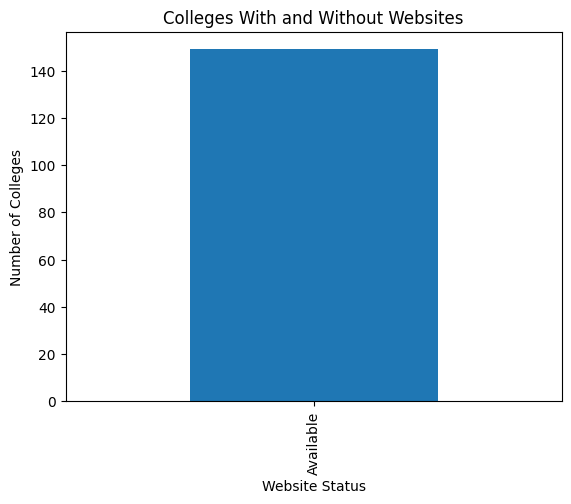

In [87]:
#Colleges With and Without Websites
website_status = df1["website"].apply( lambda x: "Available"if x != "N/A" else "Missing")
website_status.value_counts().plot(kind="bar")
plt.title("Colleges With and Without Websites")
plt.xlabel("Website Status")
plt.ylabel("Number of Colleges")
plt.show()

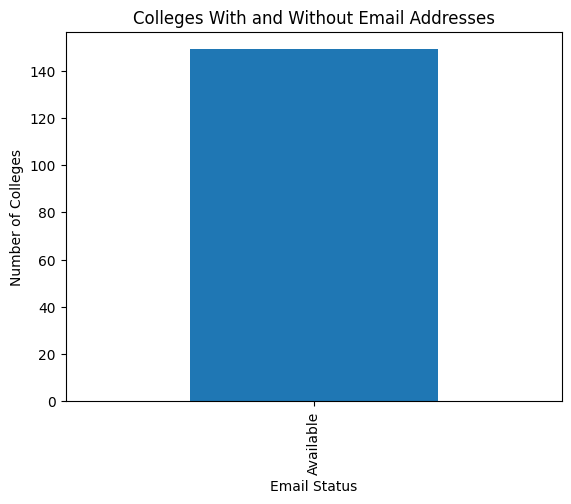

In [88]:
#Colleges With and Without Email Addresses
email_status = df1["Email ID"].apply( lambda x: "Available"if x != "N/A"else "Missing")
email_status.value_counts().plot(kind="bar")
plt.title("Colleges With and Without Email Addresses")
plt.xlabel("Email Status")
plt.ylabel("Number of Colleges")
plt.show()

         Information  Count
0    Phone Available    147
1    Email Available    147
2  Website Available    147


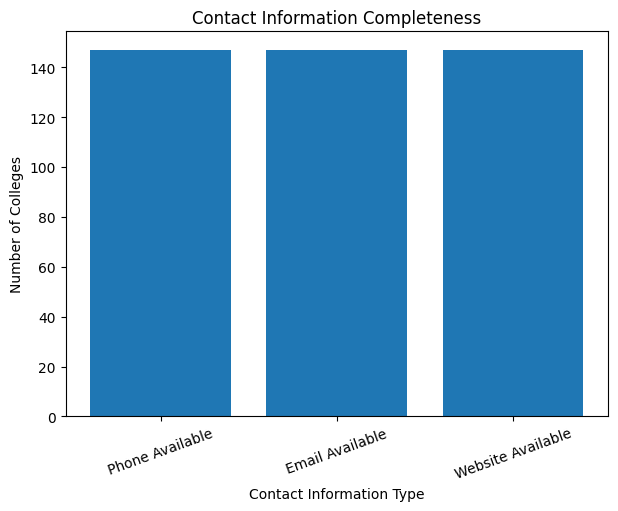

In [90]:
#Contact Information Completeness
contact_complete = pd.DataFrame({

    "Information": [
        "Phone Available",
        "Email Available",
        "Website Available"
    ],"Count": [(df["Contact"] != "N/A").sum(),(df["Email ID"] != "N/A").sum(),(df["website"] != "N/A").sum()]})
print(contact_complete)
# Visualization
plt.figure(figsize=(7,5))
plt.bar(contact_complete["Information"],contact_complete["Count"])
plt.title( "Contact Information Completeness")
plt.xlabel( "Contact Information Type")
plt.ylabel("Number of Colleges")
plt.xticks(rotation=20)
plt.show()

# Observations / Insights

- Most affiliated colleges have website URLs available, showing that many colleges maintain an online presence.
- Some colleges do not provide email addresses in their profile pages, which may reduce accessibility for online communication.
- Contact information completeness varies between colleges. Some colleges provide all details (phone, email, website), while others have incomplete records.
  
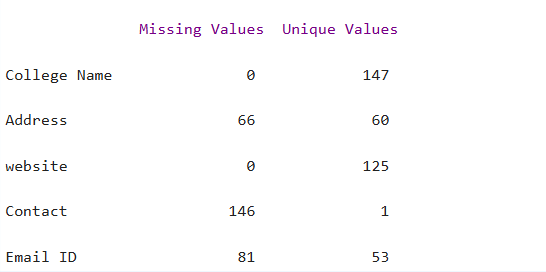